In [4]:
!pip install medmnist

Using device: cuda
GPU: Tesla T4
PneumoniaMNIST — Train: 4708, Val: 524, Test: 624
DermaMNIST — Train: 7007, Val: 1003, Test: 2005
Data loaders ready.
CNN output shape (Pneumonia): torch.Size([1, 2])
CNN output shape (Derma): torch.Size([1, 7])
Total parameters (Derma CNN): 148,775
CUSTOM CNN — PneumoniaMNIST
  Epoch   1/30 | Train Loss: 0.2925 Acc: 0.8783 | Val Loss: 0.1783 Acc: 0.9408 AUC: 0.9771 <- best
  Epoch   2/30 | Train Loss: 0.1849 Acc: 0.9274 | Val Loss: 0.1421 Acc: 0.9656 AUC: 0.9899 <- best
  Epoch   5/30 | Train Loss: 0.1300 Acc: 0.9511 | Val Loss: 0.0960 Acc: 0.9656 AUC: 0.9940 
  Epoch   7/30 | Train Loss: 0.1097 Acc: 0.9592 | Val Loss: 0.0752 Acc: 0.9695 AUC: 0.9967 <- best
  Epoch   9/30 | Train Loss: 0.0886 Acc: 0.9656 | Val Loss: 0.0800 Acc: 0.9714 AUC: 0.9971 <- best
  Epoch  10/30 | Train Loss: 0.0890 Acc: 0.9650 | Val Loss: 0.0708 Acc: 0.9771 AUC: 0.9969 <- best
  Epoch  12/30 | Train Loss: 0.0748 Acc: 0.9715 | Val Loss: 0.0615 Acc: 0.9790 AUC: 0.9968 <- best
  E

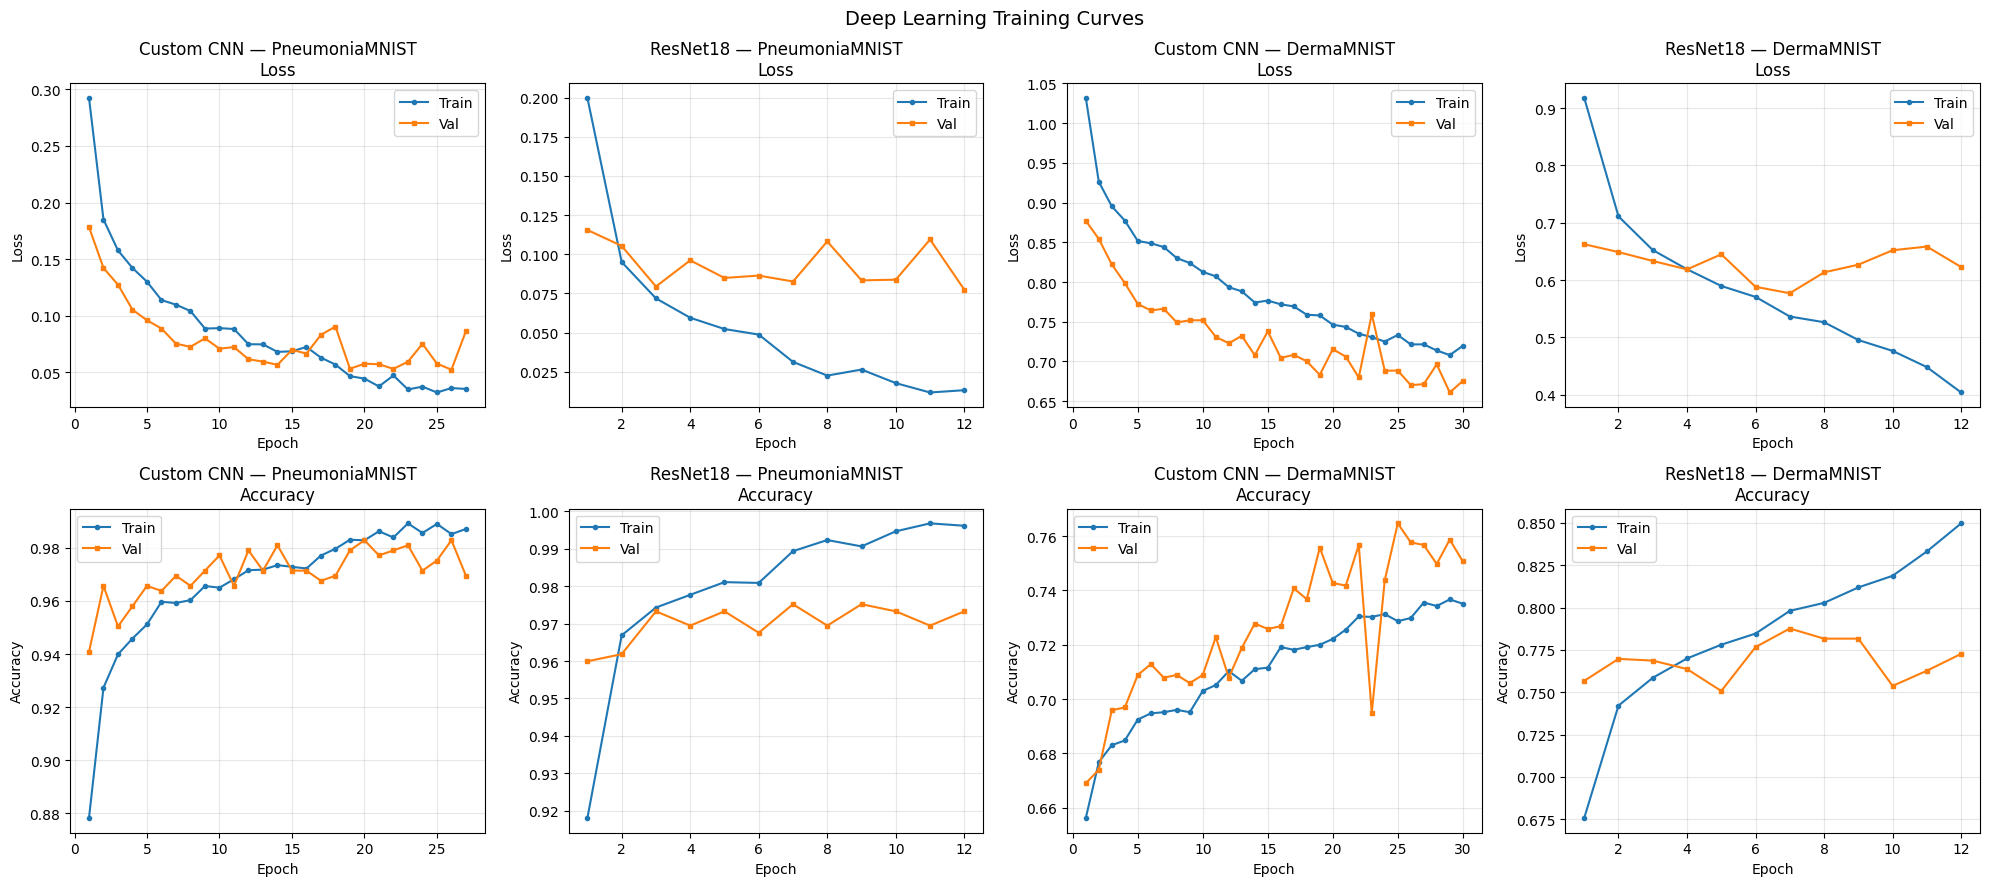

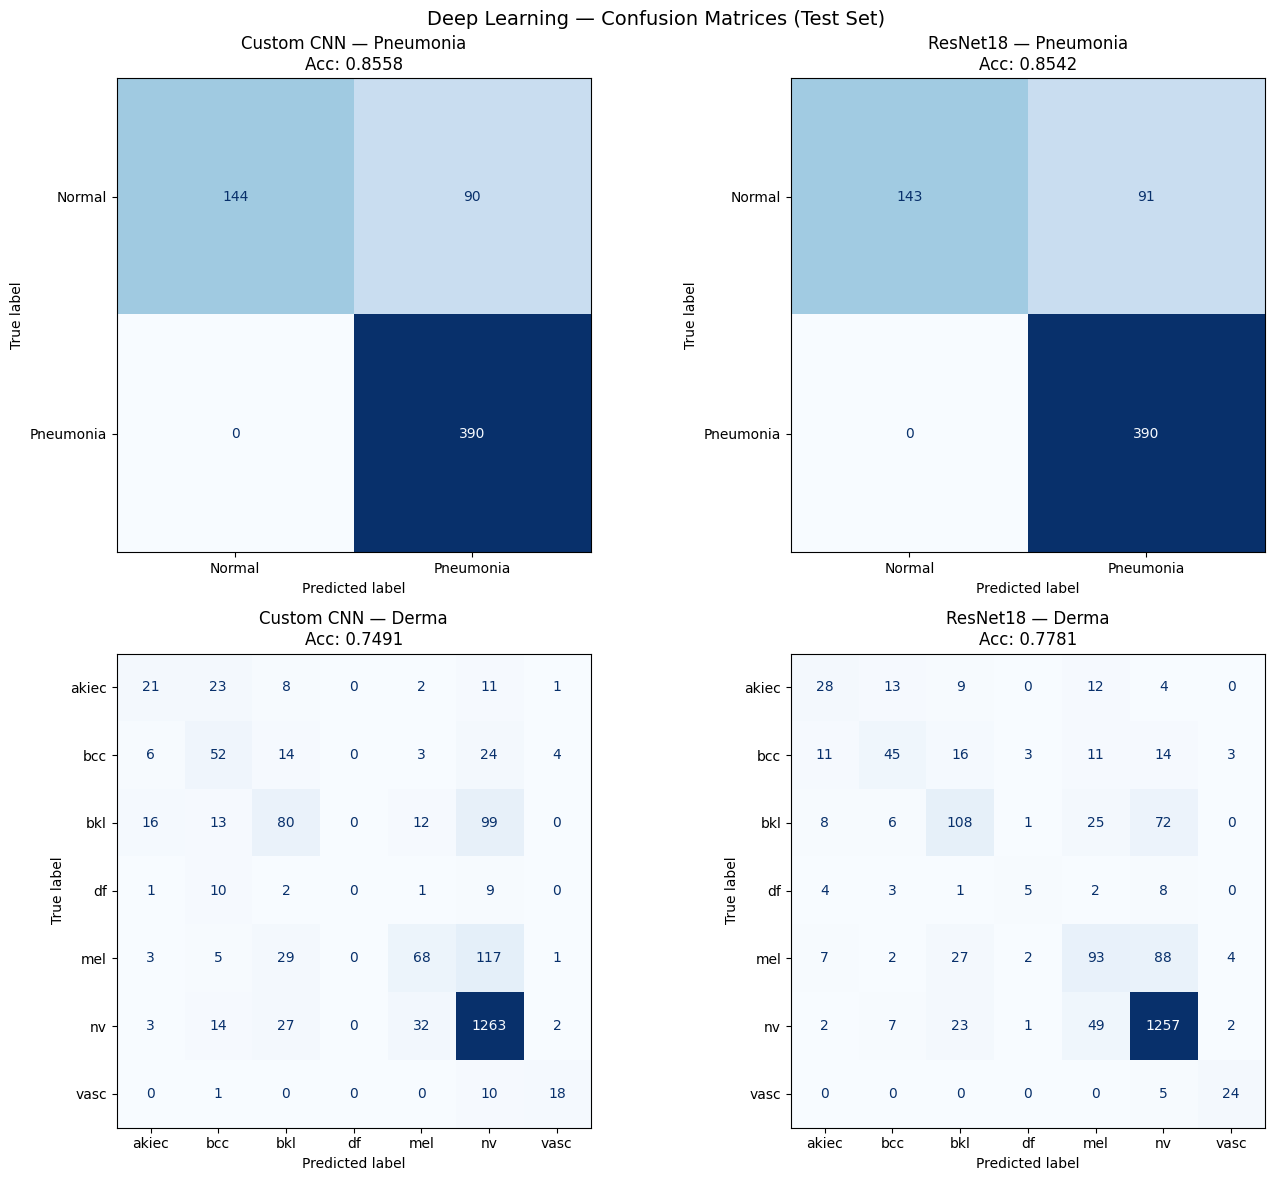

GRAND COMPARISON — All Methods (Best Val Accuracy → Test Performance)

--- PneumoniaMNIST ---
Method                          Train Acc    Val Acc   Test Acc   Test AUC    Test F1
----------------------------------------------------------------------------------
Logistic Reg (PCA=100)             0.9552     0.9599     0.8365     0.9884     0.9731
LDA (PCA=50)                       0.9560     0.9561     0.8526     0.9880     0.9706
kNN (PCA=100, k=25)                0.9528     0.9637     0.8269     0.9879     0.9759
SVM-RBF (PCA=30)                   0.9928     0.9771     0.8606     0.9951     0.9845
Random Forest (PCA=100)            1.0000     0.9408     0.8429     0.9812          —
AdaBoost (PCA=100)                 0.9762     0.9561     0.8429     0.9828          —
Custom CNN                         0.9913     0.9828     0.8558     0.9742     0.8966
ResNet18 (fine-tuned)              0.9949     0.9752     0.8542     0.9631     0.8955

--- DermaMNIST ---
Method                       

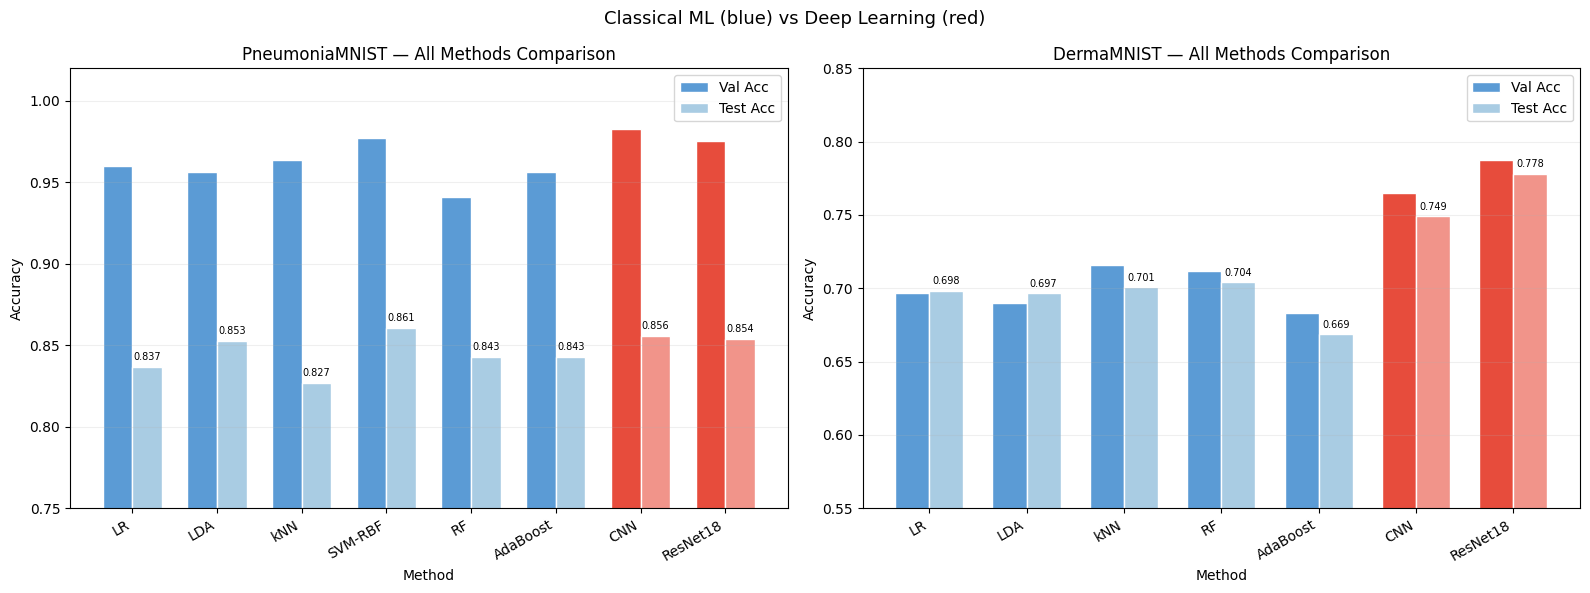


GENERALIZATION GAP ANALYSIS — Classical vs Deep Learning

--- PneumoniaMNIST ---
Method                          Train Acc   Test Acc        Gap
--------------------------------------------------------------
SVM-RBF (best classical)           0.9928     0.8606     0.1322
Custom CNN                         0.9913     0.8558     0.1355
ResNet18 (fine-tuned)              0.9949     0.8542     0.1407

--- DermaMNIST ---
Method                          Train Acc   Test Acc        Gap
--------------------------------------------------------------
kNN (best classical)               0.7287     0.7007     0.0280
Custom CNN                         0.7638     0.7491     0.0147
ResNet18 (fine-tuned)              0.8247     0.7781     0.0467


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
import medmnist
from medmnist import PneumoniaMNIST, DermaMNIST
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import warnings
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

transform_pn_cnn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

transform_dm_cnn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

transform_pn_resnet = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_dm_resnet = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_pn_resnet_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_dm_resnet_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

pn_train_cnn = PneumoniaMNIST(split='train', transform=transform_pn_cnn, download=True)
pn_val_cnn = PneumoniaMNIST(split='val', transform=transform_pn_cnn, download=True)
pn_test_cnn = PneumoniaMNIST(split='test', transform=transform_pn_cnn, download=True)

dm_train_cnn = DermaMNIST(split='train', transform=transform_dm_cnn, download=True)
dm_val_cnn = DermaMNIST(split='val', transform=transform_dm_cnn, download=True)
dm_test_cnn = DermaMNIST(split='test', transform=transform_dm_cnn, download=True)

pn_train_resnet = PneumoniaMNIST(split='train', transform=transform_pn_resnet_train, download=True)
pn_val_resnet = PneumoniaMNIST(split='val', transform=transform_pn_resnet, download=True)
pn_test_resnet = PneumoniaMNIST(split='test', transform=transform_pn_resnet, download=True)

dm_train_resnet = DermaMNIST(split='train', transform=transform_dm_resnet_train, download=True)
dm_val_resnet = DermaMNIST(split='val', transform=transform_dm_resnet, download=True)
dm_test_resnet = DermaMNIST(split='test', transform=transform_dm_resnet, download=True)

BATCH_SIZE = 64

pn_loaders_cnn = {
    'train': DataLoader(pn_train_cnn, batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
    'val':   DataLoader(pn_val_cnn, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
    'test':  DataLoader(pn_test_cnn, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
}
dm_loaders_cnn = {
    'train': DataLoader(dm_train_cnn, batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
    'val':   DataLoader(dm_val_cnn, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
    'test':  DataLoader(dm_test_cnn, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
}

pn_loaders_resnet = {
    'train': DataLoader(pn_train_resnet, batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
    'val':   DataLoader(pn_val_resnet, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
    'test':  DataLoader(pn_test_resnet, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
}
dm_loaders_resnet = {
    'train': DataLoader(dm_train_resnet, batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
    'val':   DataLoader(dm_val_resnet, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
    'test':  DataLoader(dm_test_resnet, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
}

print(f"PneumoniaMNIST — Train: {len(pn_train_cnn)}, Val: {len(pn_val_cnn)}, Test: {len(pn_test_cnn)}")
print(f"DermaMNIST — Train: {len(dm_train_cnn)}, Val: {len(dm_val_cnn)}, Test: {len(dm_test_cnn)}")
print("Data loaders ready.")

class SimpleCNN(nn.Module):

    def __init__(self, in_channels, num_classes):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_test = SimpleCNN(in_channels=1, num_classes=2)
dummy = torch.randn(1, 1, 28, 28)
print(f"CNN output shape (Pneumonia): {model_test(dummy).shape}")

model_test = SimpleCNN(in_channels=3, num_classes=7)
dummy = torch.randn(1, 3, 28, 28)
print(f"CNN output shape (Derma): {model_test(dummy).shape}")

total_params = sum(p.numel() for p in model_test.parameters())
print(f"Total parameters (Derma CNN): {total_params:,}")

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device, num_classes):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    avg_loss = running_loss / len(all_labels)

    if num_classes == 2:
        auc = roc_auc_score(all_labels, all_probs[:, 1])
        f1 = f1_score(all_labels, all_preds)
    else:
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
        f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, acc, auc, f1


def train_model(model, loaders, criterion, optimizer, scheduler, device,
                num_classes, num_epochs=25, patience=7):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
               'val_auc': [], 'val_f1': []}
    best_val_acc = 0.0
    best_state = None
    epochs_no_improve = 0
    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, loaders['train'],
                                                 criterion, optimizer, device)
        val_loss, val_acc, val_auc, val_f1 = evaluate(model, loaders['val'],
                                                        criterion, device, num_classes)

        if scheduler is not None:
            scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)
        history['val_f1'].append(val_f1)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if (epoch + 1) % 5 == 0 or epoch == 0 or epochs_no_improve == 0:
            print(f"  Epoch {epoch+1:>3d}/{num_epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} AUC: {val_auc:.4f} "
                  f"{'<- best' if epochs_no_improve == 0 else ''}")

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
            break

    total_time = time.time() - start_time
    print(f"Training complete in {total_time:.1f}s | Best val_acc: {best_val_acc:.4f}")
    model.load_state_dict(best_state)
    model.to(device)
    return history, total_time

print("=" * 70)
print("CUSTOM CNN — PneumoniaMNIST")
print("=" * 70)

cnn_pn = SimpleCNN(in_channels=1, num_classes=2).to(device)
criterion_pn = nn.CrossEntropyLoss()
optimizer_pn = optim.Adam(cnn_pn.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_pn = optim.lr_scheduler.ReduceLROnPlateau(optimizer_pn, mode='min',
                                                      patience=3, factor=0.5)

history_cnn_pn, time_cnn_pn = train_model(
    cnn_pn, pn_loaders_cnn, criterion_pn, optimizer_pn, scheduler_pn,
    device, num_classes=2, num_epochs=30, patience=7
)
_, cnn_pn_test_acc, cnn_pn_test_auc, cnn_pn_test_f1 = evaluate(
    cnn_pn, pn_loaders_cnn['test'], criterion_pn, device, num_classes=2
)
_, cnn_pn_train_acc, _, _ = evaluate(
    cnn_pn, pn_loaders_cnn['train'], criterion_pn, device, num_classes=2
)
print(f"\n  Final — Train Acc: {cnn_pn_train_acc:.4f} | Test Acc: {cnn_pn_test_acc:.4f} | "
      f"Test AUC: {cnn_pn_test_auc:.4f} | Test F1: {cnn_pn_test_f1:.4f}")
print("\n" + "=" * 70)
print("CUSTOM CNN — DermaMNIST")
print("=" * 70)

cnn_dm = SimpleCNN(in_channels=3, num_classes=7).to(device)
criterion_dm = nn.CrossEntropyLoss()
optimizer_dm = optim.Adam(cnn_dm.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_dm = optim.lr_scheduler.ReduceLROnPlateau(optimizer_dm, mode='min',
                                                      patience=3, factor=0.5)
history_cnn_dm, time_cnn_dm = train_model(
    cnn_dm, dm_loaders_cnn, criterion_dm, optimizer_dm, scheduler_dm,
    device, num_classes=7, num_epochs=30, patience=7
)
_, cnn_dm_test_acc, cnn_dm_test_auc, cnn_dm_test_f1 = evaluate(
    cnn_dm, dm_loaders_cnn['test'], criterion_dm, device, num_classes=7
)
_, cnn_dm_train_acc, _, _ = evaluate(
    cnn_dm, dm_loaders_cnn['train'], criterion_dm, device, num_classes=7
)
print(f"\n  Final — Train Acc: {cnn_dm_train_acc:.4f} | Test Acc: {cnn_dm_test_acc:.4f} | "
      f"Test AUC: {cnn_dm_test_auc:.4f} | Test F1: {cnn_dm_test_f1:.4f}")

def get_resnet18(num_classes, freeze_early=True):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if freeze_early:
        for name, param in model.named_parameters():
            if any(name.startswith(prefix) for prefix in ['conv1', 'bn1', 'layer1', 'layer2']):
                param.requires_grad = False
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_features, num_classes)
    )
    return model

print("=" * 70)
print("RESNET18 (fine-tuned) — PneumoniaMNIST")
print("=" * 70)

resnet_pn = get_resnet18(num_classes=2, freeze_early=True).to(device)
criterion_pn_r = nn.CrossEntropyLoss()
optimizer_pn_r = optim.Adam(filter(lambda p: p.requires_grad, resnet_pn.parameters()),
                             lr=1e-4, weight_decay=1e-4)
scheduler_pn_r = optim.lr_scheduler.ReduceLROnPlateau(optimizer_pn_r, mode='min',
                                                        patience=3, factor=0.5)

trainable = sum(p.numel() for p in resnet_pn.parameters() if p.requires_grad)
total = sum(p.numel() for p in resnet_pn.parameters())
print(f"  Parameters: {total:,} total, {trainable:,} trainable ({100*trainable/total:.1f}%)")

history_resnet_pn, time_resnet_pn = train_model(
    resnet_pn, pn_loaders_resnet, criterion_pn_r, optimizer_pn_r, scheduler_pn_r,
    device, num_classes=2, num_epochs=20, patience=5
)

_, resnet_pn_test_acc, resnet_pn_test_auc, resnet_pn_test_f1 = evaluate(
    resnet_pn, pn_loaders_resnet['test'], criterion_pn_r, device, num_classes=2
)
_, resnet_pn_train_acc, _, _ = evaluate(
    resnet_pn, pn_loaders_resnet['train'], criterion_pn_r, device, num_classes=2
)
print(f"\n  Final — Train Acc: {resnet_pn_train_acc:.4f} | Test Acc: {resnet_pn_test_acc:.4f} | "
      f"Test AUC: {resnet_pn_test_auc:.4f} | Test F1: {resnet_pn_test_f1:.4f}")

print("\n" + "=" * 70)
print("RESNET18 (fine-tuned) — DermaMNIST")
print("=" * 70)

resnet_dm = get_resnet18(num_classes=7, freeze_early=True).to(device)
criterion_dm_r = nn.CrossEntropyLoss()
optimizer_dm_r = optim.Adam(filter(lambda p: p.requires_grad, resnet_dm.parameters()),
                             lr=1e-4, weight_decay=1e-4)
scheduler_dm_r = optim.lr_scheduler.ReduceLROnPlateau(optimizer_dm_r, mode='min',
                                                        patience=3, factor=0.5)

trainable = sum(p.numel() for p in resnet_dm.parameters() if p.requires_grad)
total = sum(p.numel() for p in resnet_dm.parameters())
print(f"  Parameters: {total:,} total, {trainable:,} trainable ({100*trainable/total:.1f}%)")

history_resnet_dm, time_resnet_dm = train_model(
    resnet_dm, dm_loaders_resnet, criterion_dm_r, optimizer_dm_r, scheduler_dm_r,
    device, num_classes=7, num_epochs=20, patience=5
)

_, resnet_dm_test_acc, resnet_dm_test_auc, resnet_dm_test_f1 = evaluate(
    resnet_dm, dm_loaders_resnet['test'], criterion_dm_r, device, num_classes=7
)
_, resnet_dm_train_acc, _, _ = evaluate(
    resnet_dm, dm_loaders_resnet['train'], criterion_dm_r, device, num_classes=7
)
print(f"\n  Final — Train Acc: {resnet_dm_train_acc:.4f} | Test Acc: {resnet_dm_test_acc:.4f} | "
      f"Test AUC: {resnet_dm_test_auc:.4f} | Test F1: {resnet_dm_test_f1:.4f}")

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

histories = [
    (history_cnn_pn, 'Custom CNN — PneumoniaMNIST'),
    (history_resnet_pn, 'ResNet18 — PneumoniaMNIST'),
    (history_cnn_dm, 'Custom CNN — DermaMNIST'),
    (history_resnet_dm, 'ResNet18 — DermaMNIST'),
]

for col, (hist, title) in enumerate(histories):
    epochs = range(1, len(hist['train_loss']) + 1)

    axes[0, col].plot(epochs, hist['train_loss'], 'o-', markersize=3, label='Train')
    axes[0, col].plot(epochs, hist['val_loss'], 's-', markersize=3, label='Val')
    axes[0, col].set_xlabel('Epoch')
    axes[0, col].set_ylabel('Loss')
    axes[0, col].set_title(f'{title}\nLoss')
    axes[0, col].legend()
    axes[0, col].grid(True, alpha=0.3)

    axes[1, col].plot(epochs, hist['train_acc'], 'o-', markersize=3, label='Train')
    axes[1, col].plot(epochs, hist['val_acc'], 's-', markersize=3, label='Val')
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].set_ylabel('Accuracy')
    axes[1, col].set_title(f'{title}\nAccuracy')
    axes[1, col].legend()
    axes[1, col].grid(True, alpha=0.3)

plt.suptitle('Deep Learning Training Curves', fontsize=14)
plt.tight_layout()
plt.show()

@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        images = images.to(device)
        labels = labels.squeeze().long()
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

pn_class_names = ['Normal', 'Pneumonia']
for ax, model, loader, title in [
    (axes[0, 0], cnn_pn, pn_loaders_cnn['test'], 'Custom CNN — Pneumonia'),
    (axes[0, 1], resnet_pn, pn_loaders_resnet['test'], 'ResNet18 — Pneumonia'),
]:
    preds, labels = get_predictions(model, loader, device)
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=pn_class_names)
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    acc = accuracy_score(labels, preds)
    ax.set_title(f'{title}\nAcc: {acc:.4f}')

dm_class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
for ax, model, loader, title in [
    (axes[1, 0], cnn_dm, dm_loaders_cnn['test'], 'Custom CNN — Derma'),
    (axes[1, 1], resnet_dm, dm_loaders_resnet['test'], 'ResNet18 — Derma'),
]:
    preds, labels = get_predictions(model, loader, device)
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=dm_class_names)
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    acc = accuracy_score(labels, preds)
    ax.set_title(f'{title}\nAcc: {acc:.4f}')

plt.suptitle('Deep Learning — Confusion Matrices (Test Set)', fontsize=14)
plt.tight_layout()
plt.show()

print("=" * 95)
print("GRAND COMPARISON — All Methods (Best Val Accuracy → Test Performance)")
print("=" * 95)

print("\n--- PneumoniaMNIST ---")
print(f"{'Method':<30s} {'Train Acc':>10s} {'Val Acc':>10s} {'Test Acc':>10s} "
      f"{'Test AUC':>10s} {'Test F1':>10s}")
print("-" * 82)

classical_pn = [
    ("Logistic Reg (PCA=100)",  0.9552, 0.9599, 0.8365, 0.9884, 0.9731),
    ("LDA (PCA=50)",            0.9560, 0.9561, 0.8526, 0.9880, 0.9706),
    ("kNN (PCA=100, k=25)",     0.9528, 0.9637, 0.8269, 0.9879, 0.9759),
    ("SVM-RBF (PCA=30)",        0.9928, 0.9771, 0.8606, 0.9951, 0.9845),
    ("Random Forest (PCA=100)", 1.0000, 0.9408, 0.8429, 0.9812, None),
    ("AdaBoost (PCA=100)",      0.9762, 0.9561, 0.8429, 0.9828, None),
]

for name, tr, va, te, auc, f1 in classical_pn:
    f1_str = f"{f1:.4f}" if f1 is not None else "   —"
    print(f"{name:<30s} {tr:>10.4f} {va:>10.4f} {te:>10.4f} {auc:>10.4f} {f1_str:>10s}")

best_cnn_pn_val = max(history_cnn_pn['val_acc'])
best_resnet_pn_val = max(history_resnet_pn['val_acc'])

print(f"{'Custom CNN':<30s} {cnn_pn_train_acc:>10.4f} {best_cnn_pn_val:>10.4f} "
      f"{cnn_pn_test_acc:>10.4f} {cnn_pn_test_auc:>10.4f} {cnn_pn_test_f1:>10.4f}")
print(f"{'ResNet18 (fine-tuned)':<30s} {resnet_pn_train_acc:>10.4f} {best_resnet_pn_val:>10.4f} "
      f"{resnet_pn_test_acc:>10.4f} {resnet_pn_test_auc:>10.4f} {resnet_pn_test_f1:>10.4f}")

print("\n--- DermaMNIST ---")
print(f"{'Method':<30s} {'Train Acc':>10s} {'Val Acc':>10s} {'Test Acc':>10s} "
      f"{'Test AUC':>10s} {'Test F1':>10s}")
print("-" * 82)

classical_dm = [
    ("Logistic Reg (PCA=75)",   0.7129, 0.6969, 0.6983, 0.8670, 0.3420),
    ("LDA (PCA=50)",            0.7026, 0.6899, 0.6968, 0.8698, 0.3135),
    ("kNN (PCA=50, k=15)",      0.7287, 0.7159, 0.7007, 0.7926, 0.2888),
    ("Random Forest (PCA=50)",  1.0000, 0.7119, 0.7042, 0.8737, None),
    ("AdaBoost (PCA=50)",       0.6787, 0.6830, 0.6688, 0.8008, None),
]

for name, tr, va, te, auc, f1 in classical_dm:
    f1_str = f"{f1:.4f}" if f1 is not None else "   —"
    print(f"{name:<30s} {tr:>10.4f} {va:>10.4f} {te:>10.4f} {auc:>10.4f} {f1_str:>10s}")

best_cnn_dm_val = max(history_cnn_dm['val_acc'])
best_resnet_dm_val = max(history_resnet_dm['val_acc'])

print(f"{'Custom CNN':<30s} {cnn_dm_train_acc:>10.4f} {best_cnn_dm_val:>10.4f} "
      f"{cnn_dm_test_acc:>10.4f} {cnn_dm_test_auc:>10.4f} {cnn_dm_test_f1:>10.4f}")
print(f"{'ResNet18 (fine-tuned)':<30s} {resnet_dm_train_acc:>10.4f} {best_resnet_dm_val:>10.4f} "
      f"{resnet_dm_test_acc:>10.4f} {resnet_dm_test_auc:>10.4f} {resnet_dm_test_f1:>10.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
methods_pn = ['LR', 'LDA', 'kNN', 'SVM-RBF', 'RF', 'AdaBoost', 'CNN', 'ResNet18']
val_accs_pn = [0.9599, 0.9561, 0.9637, 0.9771, 0.9408, 0.9561,
               best_cnn_pn_val, best_resnet_pn_val]
test_accs_pn = [0.8365, 0.8526, 0.8269, 0.8606, 0.8429, 0.8429,
                cnn_pn_test_acc, resnet_pn_test_acc]

x = np.arange(len(methods_pn))
width = 0.35
colors_val = ['#5B9BD5'] * 6 + ['#E74C3C'] * 2
colors_test = ['#A9CCE3'] * 6 + ['#F1948A'] * 2

bars1 = axes[0].bar(x - width/2, val_accs_pn, width, label='Val Acc', color=colors_val, edgecolor='white')
bars2 = axes[0].bar(x + width/2, test_accs_pn, width, label='Test Acc', color=colors_test, edgecolor='white')
for bar, val in zip(bars2, test_accs_pn):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=7)
axes[0].set_xlabel('Method')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('PneumoniaMNIST — All Methods Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods_pn, rotation=30, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.2, axis='y')
axes[0].set_ylim(0.75, 1.02)
methods_dm = ['LR', 'LDA', 'kNN', 'RF', 'AdaBoost', 'CNN', 'ResNet18']
val_accs_dm = [0.6969, 0.6899, 0.7159, 0.7119, 0.6830,
               best_cnn_dm_val, best_resnet_dm_val]
test_accs_dm = [0.6983, 0.6968, 0.7007, 0.7042, 0.6688,
                cnn_dm_test_acc, resnet_dm_test_acc]

x = np.arange(len(methods_dm))
colors_val = ['#5B9BD5'] * 5 + ['#E74C3C'] * 2
colors_test = ['#A9CCE3'] * 5 + ['#F1948A'] * 2

bars1 = axes[1].bar(x - width/2, val_accs_dm, width, label='Val Acc', color=colors_val, edgecolor='white')
bars2 = axes[1].bar(x + width/2, test_accs_dm, width, label='Test Acc', color=colors_test, edgecolor='white')
for bar, val in zip(bars2, test_accs_dm):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=7)
axes[1].set_xlabel('Method')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('DermaMNIST — All Methods Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods_dm, rotation=30, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.2, axis='y')
axes[1].set_ylim(0.55, 0.85)

plt.suptitle('Classical ML (blue) vs Deep Learning (red)', fontsize=13)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("GENERALIZATION GAP ANALYSIS — Classical vs Deep Learning")
print("=" * 70)

print("\n--- PneumoniaMNIST ---")
print(f"{'Method':<30s} {'Train Acc':>10s} {'Test Acc':>10s} {'Gap':>10s}")
print("-" * 62)
pn_gap_data = [
    ("SVM-RBF (best classical)", 0.9928, 0.8606),
    ("Custom CNN", cnn_pn_train_acc, cnn_pn_test_acc),
    ("ResNet18 (fine-tuned)", resnet_pn_train_acc, resnet_pn_test_acc),
]
for name, tr, te in pn_gap_data:
    print(f"{name:<30s} {tr:>10.4f} {te:>10.4f} {abs(tr - te):>10.4f}")

print("\n--- DermaMNIST ---")
print(f"{'Method':<30s} {'Train Acc':>10s} {'Test Acc':>10s} {'Gap':>10s}")
print("-" * 62)
dm_gap_data = [
    ("kNN (best classical)", 0.7287, 0.7007),
    ("Custom CNN", cnn_dm_train_acc, cnn_dm_test_acc),
    ("ResNet18 (fine-tuned)", resnet_dm_train_acc, resnet_dm_test_acc),
]
for name, tr, te in dm_gap_data:
    print(f"{name:<30s} {tr:>10.4f} {te:>10.4f} {abs(tr - te):>10.4f}")